# Fase 4 (parte A) — Modelos de Machine Learning clásico
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas

---
Entrenamos **dos** modelos clásicos sobre características extraídas a mano
(HOG + histograma de color HSV, 1860 dimensiones):

- **Random Forest**
- **XGBoost**

Ambos con **ajuste de hiperparámetros por `GridSearchCV` (k=5)** optimizando
F1-macro (robusto al desbalanceo). Comparamos contra una **línea base** trivial
(clase mayoritaria). Selección final por F1-macro en **validación**; reporte
honesto en **test**.

In [1]:
# Bootstrap
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, joblib, time
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb

from src.config import QUALITY_CLASSES, MODELS_DIR, FIGURES_DIR, SEED
from src.data.preprocessing import load_manifest
from src.features.extract import build_feature_matrix

## 1. Cargar características (cacheadas en Fase 3 / extracción C4)

In [2]:
Xtr, ytr = build_feature_matrix(load_manifest('train'), 'train')
Xva, yva = build_feature_matrix(load_manifest('val'),   'val')
Xte, yte = build_feature_matrix(load_manifest('test'),  'test')
print("train", Xtr.shape, "| val", Xva.shape, "| test", Xte.shape)
print("clases (idx->nombre):", dict(enumerate(QUALITY_CLASSES)))

train (2851, 1860) | val (617, 1860) | test (606, 1860)
clases (idx->nombre): {0: 'Premium', 1: 'Estándar', 2: 'Descarte'}


## 2. Línea base (baseline)
Un clasificador que siempre predice la clase mayoritaria. Cualquier modelo útil
debe superarlo claramente, sobre todo en **F1-macro** (que penaliza ignorar
clases minoritarias).

In [3]:
dummy = DummyClassifier(strategy='most_frequent').fit(Xtr, ytr)
base_acc = accuracy_score(yte, dummy.predict(Xte))
base_f1  = f1_score(yte, dummy.predict(Xte), average='macro')
print(f"Baseline  ->  accuracy={base_acc:.3f} | f1_macro={base_f1:.3f}")

Baseline  ->  accuracy=0.365 | f1_macro=0.178


## 3. Random Forest + GridSearchCV
`class_weight='balanced'` compensa el desbalanceo residual tras el *cap*.

In [4]:
rf_grid = {'n_estimators':[200,400], 'max_depth':[None,20], 'min_samples_split':[2,5]}
t=time.time()
rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=1),
    rf_grid, cv=5, scoring='f1_macro', n_jobs=-1)
rf.fit(Xtr, ytr)
print(f"[{time.time()-t:.0f}s] mejores hiperparámetros:", rf.best_params_)
print(f"F1-macro CV={rf.best_score_:.3f} | val={f1_score(yva, rf.predict(Xva), average='macro'):.3f}")

[154s] mejores hiperparámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 400}
F1-macro CV=0.913 | val=0.912


## 4. XGBoost + GridSearchCV

In [5]:
xgb_grid = {'learning_rate':[0.1,0.3], 'max_depth':[4,6], 'n_estimators':[200,400]}
t=time.time()
xg = GridSearchCV(
    xgb.XGBClassifier(tree_method='hist', random_state=SEED, n_jobs=1,
                      eval_metric='mlogloss'),
    xgb_grid, cv=5, scoring='f1_macro', n_jobs=-1)
xg.fit(Xtr, ytr)
print(f"[{time.time()-t:.0f}s] mejores hiperparámetros:", xg.best_params_)
print(f"F1-macro CV={xg.best_score_:.3f} | val={f1_score(yva, xg.predict(Xva), average='macro'):.3f}")

/home/juan-pablo/anaconda3/envs/fruit-quality/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[1085s] mejores hiperparámetros: {'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 200}
F1-macro CV=0.930 | val=0.941


## 5. Evaluación en el conjunto de prueba
Reportamos métricas por clase y matriz de confusión de ambos modelos.

In [6]:
def evaluate(model, name):
    pred = model.predict(Xte)
    acc = accuracy_score(yte, pred); f1 = f1_score(yte, pred, average='macro')
    print(f"=== {name} ===  accuracy={acc:.3f} | f1_macro={f1:.3f}")
    print(classification_report(yte, pred, target_names=QUALITY_CLASSES, digits=3))
    return acc, f1, pred

rf_acc, rf_f1, rf_pred = evaluate(rf, "Random Forest")
xg_acc, xg_f1, xg_pred = evaluate(xg, "XGBoost")

=== Random Forest ===  accuracy=0.932 | f1_macro=0.932
              precision    recall  f1-score   support

     Premium      0.941     0.916     0.928       225
    Estándar      0.936     0.919     0.927       160
    Descarte      0.922     0.959     0.940       221

    accuracy                          0.932       606
   macro avg      0.933     0.931     0.932       606
weighted avg      0.933     0.932     0.932       606

=== XGBoost ===  accuracy=0.937 | f1_macro=0.937
              precision    recall  f1-score   support

     Premium      0.967     0.902     0.933       225
    Estándar      0.911     0.956     0.933       160
    Descarte      0.930     0.959     0.944       221

    accuracy                          0.937       606
   macro avg      0.936     0.939     0.937       606
weighted avg      0.938     0.937     0.937       606



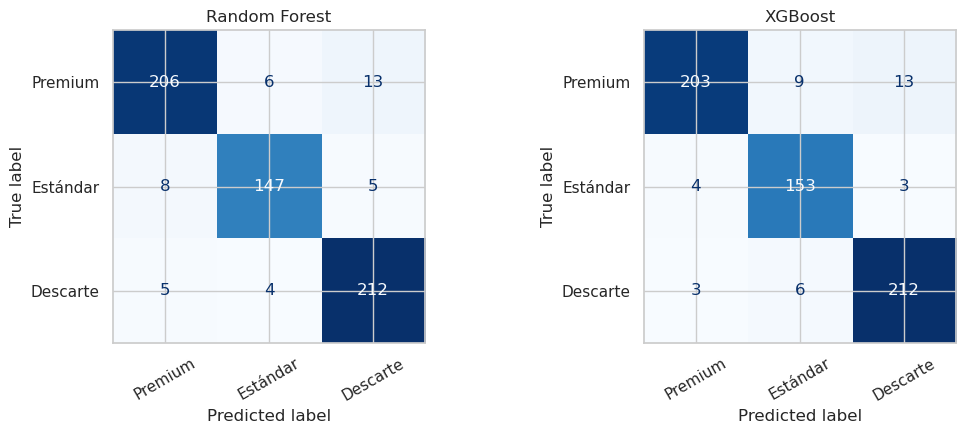

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a,(pred,name) in zip(ax, [(rf_pred,"Random Forest"),(xg_pred,"XGBoost")]):
    cm = confusion_matrix(yte, pred)
    ConfusionMatrixDisplay(cm, display_labels=QUALITY_CLASSES).plot(ax=a, cmap='Blues', colorbar=False)
    a.set_title(name); a.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fase4_ml_confusion.pdf", bbox_inches="tight")
plt.show()

## 6. Importancia de características (Random Forest)
Qué tipo de información (forma vía HOG vs color) pesa más en la decisión.

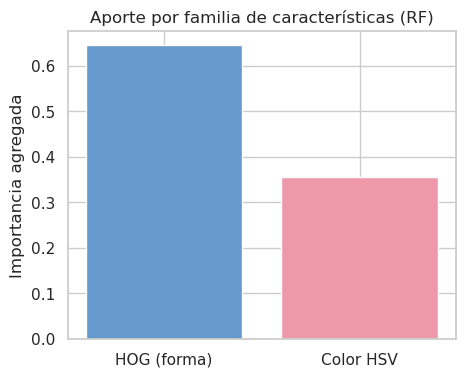

HOG=0.65 | Color=0.35


In [8]:
best_rf = rf.best_estimator_
imp = best_rf.feature_importances_
# Las primeras 1764 dims son HOG; las últimas 96 son color HSV.
n_hog = 1764
hog_imp = imp[:n_hog].sum(); color_imp = imp[n_hog:].sum()
plt.figure(figsize=(5,4))
plt.bar(['HOG (forma)','Color HSV'], [hog_imp, color_imp], color=['#69c','#e9a'])
plt.ylabel('Importancia agregada'); plt.title('Aporte por familia de características (RF)')
plt.savefig(FIGURES_DIR / "fase4_ml_importancia.pdf", bbox_inches="tight")
plt.show()
print(f"HOG={hog_imp:.2f} | Color={color_imp:.2f}")

## 7. Comparativa y guardado del mejor modelo

In [9]:
results = pd.DataFrame({
    'modelo':['Baseline','Random Forest','XGBoost'],
    'accuracy':[base_acc, rf_acc, xg_acc],
    'f1_macro':[base_f1, rf_f1, xg_f1],
}).set_index('modelo')
print(results.round(3))

best_name, best_model = max(
    [('random_forest', rf.best_estimator_, rf_f1), ('xgboost', xg.best_estimator_, xg_f1)],
    key=lambda t: t[2])[:2]
joblib.dump(best_model, MODELS_DIR / "best_quality_ml.pkl")
joblib.dump(rf.best_estimator_, MODELS_DIR / "random_forest.pkl")
joblib.dump(xg.best_estimator_, MODELS_DIR / "xgboost.pkl")
print(f"\nMejor modelo ML: {best_name} -> guardado en models/saved/best_quality_ml.pkl")

               accuracy  f1_macro
modelo                           
Baseline          0.365     0.178
Random Forest     0.932     0.932
XGBoost           0.937     0.937

Mejor modelo ML: xgboost -> guardado en models/saved/best_quality_ml.pkl


## Resumen
- Dos modelos ML con **GridSearchCV (k=5)** y ajuste de hiperparámetros.
- Ambos superan ampliamente la **línea base**.
- Características interpretables: **HOG (forma)** + **color HSV (apariencia)**.
- Mejor modelo guardado para el despliegue (app Streamlit).